<!-- ARTHASAATHI-PROVENANCE -->
> ## ⚠️ This notebook is demo evidence, not the running system
>
> The logic below was migrated to **`ml/src/councils/risk/emergency_fund.py`** and that module is what the application actually executes.
>
> **Role in the system:** Risk Council -> Emergency Fund Agent
>
> This notebook is preserved because its stored outputs are the record of the original analysis. **Editing the cells below will not change the system's behaviour** — change the module and its tests instead.
>
> Tests for this logic live under `tests/`, and every agent is covered by the cross-cutting contract suite in `tests/common/test_contracts.py`.


In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, END


class FinancialState(TypedDict):
    income: float
    expenses: float
    existing_emergency_fund: float
    job_type: str
    dependents: int
    has_health_insurance: bool

    emergency_fund_result: dict

In [2]:
def emergency_fund_advisor(
    income,
    expenses,
    existing_emergency_fund,
    job_type,
    dependents=0,
    has_health_insurance=True
):

    # =====================================================
    # CURRENT FUND
    # =====================================================

    current_fund = existing_emergency_fund

    # =====================================================
    # TARGET MONTHS
    # =====================================================

    base_months_map = {
        "govt": 6,
        "salaried": 6,
        "freelancer": 6,
        "business": 6
    }

    target_months = (
        base_months_map.get(job_type, 6)
        + (2 if dependents >= 1 else 0)
        + (1 if dependents >= 3 else 0)
        + (3 if not has_health_insurance else 0)
    )

    # =====================================================
    # ESSENTIAL EXPENSES
    # Replace later with actual calculation
    # =====================================================

    essential_expenses = expenses * 0.70

    # =====================================================
    # TARGET FUND
    # =====================================================

    target_fund = target_months * essential_expenses

    remaining_gap = max(
        target_fund - current_fund,
        0
    )

    # =====================================================
    # COMPLETION %
    # =====================================================

    completion = (
        min(
            100,
            round(
                (current_fund / target_fund) * 100,
                2
            )
        )
        if target_fund > 0
        else 100
    )

    # =====================================================
    # STATUS
    # =====================================================

    if completion < 25:
        status = "Critical"

    elif completion < 50:
        status = "Vulnerable"

    elif completion < 75:
        status = "Moderate"

    elif completion < 100:
        status = "Good"

    else:
        status = "Fully Prepared"

    # =====================================================
    # BUFFER STOCK THEORY
    # =====================================================

    buffer_ratio = min(
        current_fund / target_fund,
        1
    ) if target_fund > 0 else 1

    urgency = 1 - buffer_ratio

    # =====================================================
    # PRECAUTIONARY SAVING THEORY
    # =====================================================

    risk_score = 0

    risk_score += {
        "govt": 1,
        "salaried": 2,
        "freelancer": 4,
        "business": 5
    }.get(job_type, 2)

    risk_score += min(dependents, 3)

    if not has_health_insurance:
        risk_score += 2

    risk_factor = min(
        risk_score / 10,
        1
    )

    # =====================================================
    # SAVINGS CAPACITY
    # =====================================================

    monthly_surplus = max(
        income - expenses,
        0
    )

    savings_rate = (
        monthly_surplus / income
        if income > 0
        else 0
    )

    # =====================================================
    # EMERGENCY PRIORITY
    # =====================================================

    priority_score = (
        0.8 * urgency +
        0.2 * risk_factor
    )

    # =====================================================
    # RECOMMENDED ALLOCATION
    # (% of monthly surplus)
    # =====================================================

    emergency_allocation_pct = (
        priority_score *
        savings_rate *
        2
    )

    emergency_allocation_pct = max(
        0.05,
        min(emergency_allocation_pct, 0.70)
    )

    monthly_emergency_contribution = (
        monthly_surplus *
        emergency_allocation_pct
    )

    monthly_investment_contribution = (
        monthly_surplus -
        monthly_emergency_contribution
    )

    # =====================================================
    # LIQUIDITY TIERS
    # =====================================================

    cash_target = min(
        essential_expenses * 2,
        target_fund * 0.50
    )

    liquid_fund_target = (
        target_fund -
        cash_target
    )

    # =====================================================
    # TIME TO GOAL
    # =====================================================

    months_to_goal = (
        round(
            remaining_gap /
            monthly_emergency_contribution,
            1
        )
        if monthly_emergency_contribution > 0
        else None
    )

    # =====================================================
    # OUTPUT
    # =====================================================

    return {

        "target_months": target_months,

        "essential_expenses":
            round(essential_expenses, 2),

        "target_emergency_fund":
            round(target_fund, 2),

        "current_emergency_fund":
            round(current_fund, 2),

        "remaining_gap":
            round(remaining_gap, 2),

        "completion_percent":
            completion,

        "status":
            status,

        "risk_factor":
            round(risk_factor, 2),

        "urgency":
            round(urgency, 2),

        "monthly_surplus":
            round(monthly_surplus, 2),

        "savings_rate":
            round(savings_rate, 2),

        "priority_score":
            round(priority_score, 2),

        "emergency_allocation_percent":
            round(
                emergency_allocation_pct * 100,
                2
            ),

        "monthly_emergency_contribution":
            round(
                monthly_emergency_contribution,
                2
            ),

        "monthly_investment_contribution":
            round(
                monthly_investment_contribution,
                2
            ),

        "cash_target":
            round(cash_target, 2),

        "liquid_fund_target":
            round(liquid_fund_target, 2),

        "months_to_goal":
            months_to_goal
    }

In [3]:
def emergency_fund_node(state):

    result = emergency_fund_advisor(
        income=state["income"],
        expenses=state["expenses"],
        existing_emergency_fund=state["existing_emergency_fund"],
        job_type=state["job_type"],
        dependents=state["dependents"],
        has_health_insurance=state["has_health_insurance"]
    )

    return {
        "emergency_fund_result": result
    }

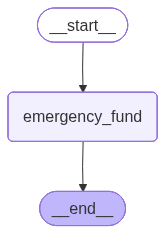

In [6]:
builder = StateGraph(FinancialState)

builder.add_node(
    "emergency_fund",
    emergency_fund_node
)

builder.set_entry_point(
    "emergency_fund"
)

builder.add_edge(
    "emergency_fund",
    END
)

graph = builder.compile()

from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [ ]:
result = graph.invoke({
    "income": 50000,
    "expenses": 35000,
    "existing_emergency_fund": 20000,
    "job_type": "salaried",
    "dependents": 1,
    "has_health_insurance": True
})

print(result["emergency_fund_result"])



{'target_months': 8, 'essential_expenses': 24500.0, 'target_emergency_fund': 196000.0, 'current_emergency_fund': 20000, 'remaining_gap': 176000.0, 'completion_percent': 10.2, 'status': 'Critical', 'risk_factor': 0.3, 'urgency': 0.9, 'monthly_surplus': 15000, 'savings_rate': 0.3, 'priority_score': 0.78, 'emergency_allocation_percent': 46.7, 'monthly_emergency_contribution': 7005.31, 'monthly_investment_contribution': 7994.69, 'cash_target': 49000.0, 'liquid_fund_target': 147000.0, 'months_to_goal': 25.1}


In [16]:

import inspect

def show_function_io(func, sample_inputs):
    sig = inspect.signature(func)

    print("INPUTS")
    print("-" * 40)

    for name, param in sig.parameters.items():
        default = (
            param.default
            if param.default != inspect.Parameter.empty
            else "Required"
        )

        print(f"{name} (default={default})")

    print("\nOUTPUTS")
    print("-" * 40)

    result = func(**sample_inputs)

    if isinstance(result, dict):
        for key, value in result.items():
            print(f"{key}: {type(value).__name__}")
    else:
        print(type(result).__name__)

sample_inputs = {
    "income": 50000,
    "expenses": 35000,
    "existing_emergency_fund": 20000,
    "job_type": "salaried"
}

show_function_io(
    emergency_fund_advisor,
    sample_inputs
)

INPUTS
----------------------------------------
income (default=Required)
expenses (default=Required)
existing_emergency_fund (default=Required)
job_type (default=Required)
dependents (default=0)
has_health_insurance (default=True)

OUTPUTS
----------------------------------------
target_months: int
essential_expenses: float
target_emergency_fund: float
current_emergency_fund: int
remaining_gap: float
completion_percent: float
status: str
risk_factor: float
urgency: float
monthly_surplus: int
savings_rate: float
priority_score: float
emergency_allocation_percent: float
monthly_emergency_contribution: float
monthly_investment_contribution: float
cash_target: float
liquid_fund_target: float
months_to_goal: float
